In [10]:
import numpy as np
from itertools import combinations, permutations
import random
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def coincidencias(lista_cumple):
    parejas = combinations(lista_cumple, 2)
    return any(dia_1 == dia_2 for dia_1, dia_2 in parejas)

# n, tamaño grupo
# N numero de repeticiones del experimento
def sim_cumple(n, N):
    contador = 0
    for _ in range(N):
        lista_sim = random.choices(range(1, 366), k=n)
        if coincidencias(lista_sim):
            contador += 1

    return contador/N

def proba_comb(n):
    producto = 1
    for i in range(1, n):
        producto *= (1-(i/365))
    return 1-producto

In [15]:
n = 50
N = 1000
num_personas = [x for x in range(1, n)]
probabilidad_combinatoria = np.array([proba_comb(x) for x in range(1,n)])
probablidad_monte_carlo = np.array([sim_cumple(x, N) for x in range(1, n)])
diferencia = np.abs(probabilidad_combinatoria-probablidad_monte_carlo)

resultados = pd.DataFrame({'Numero personas':num_personas,
                           'Probabilidad combinatoria': probabilidad_combinatoria,
                           'Probabilidad Monte Carlo': probablidad_monte_carlo,
                           'Diferencia': diferencia})

resultados

,Numero personas,Probabilidad combinatoria,Probabilidad Monte Carlo,Diferencia
0,1,0.000000,0.000,0.000000
1,2,0.002740,0.002,0.000740
2,3,0.008204,0.011,0.002796
3,4,0.016356,0.015,0.001356
4,5,0.027136,0.036,0.008864
5,6,0.040462,0.045,0.004538
6,7,0.056236,0.040,0.016236
7,8,0.074335,0.068,0.006335
8,9,0.094624,0.078,0.016624
9,10,0.116948,0.092,0.024948


In [21]:
mayor_error = resultados.nlargest(n=5, columns='Diferencia')
mayor_error
# mayor_error.head()

,Numero personas,Probabilidad combinatoria,Probabilidad Monte Carlo,Diferencia
9,10,0.116948,0.092,0.024948
8,9,0.094624,0.078,0.016624
6,7,0.056236,0.040,0.016236
21,22,0.475695,0.491,0.015305
14,15,0.252901,0.267,0.014099


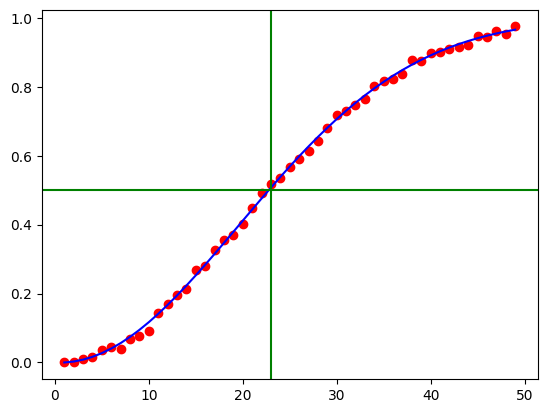

In [17]:
plt.plot(resultados['Numero personas'], resultados['Probabilidad combinatoria'], color='blue')
plt.scatter(resultados['Numero personas'], resultados['Probabilidad Monte Carlo'], color='red')
plt.axhline(y=0.5, color='green')
plt.axvline(x=23, color='green')

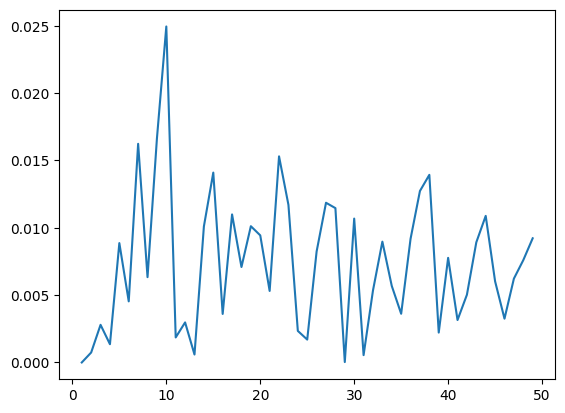

In [18]:
plt.plot(resultados['Numero personas'], resultados['Diferencia'])

La región donde mejor parece aproximarse la simulación es donde el número de personas es mayor, pero al inicio donde el número de personas es bajo, parece que la simulación tiene más error.

In [28]:
mayor_05 = resultados[resultados['Probabilidad combinatoria']>0.5]
mayor_05 = mayor_05.reset_index(drop=True)
valor_min = int(mayor_05.loc[0, 'Numero personas'])
valor_min
valor_exacto = float(mayor_05.loc[0, 'Probabilidad combinatoria'])
valor_exacto
# mayor_05

0.5072972343239854

In [34]:
num_sim = [100, 1000, 10000, 100000]
lista_sim = np.array([sim_cumple(valor_min, x) for x in num_sim])
prob_exac = np.array([valor_exacto]*4)
simulaciones_05 = pd.DataFrame({'Repeticiones': num_sim,
                                'Probabilidad simulado': lista_sim,
                                'Probabilidad exacta': prob_exac,
                                'Error': np.abs(lista_sim-prob_exac)})
simulaciones_05

,Repeticiones,Probabilidad simulado,Probabilidad exacta,Error
0,100,0.49000,0.507297,0.017297
1,1000,0.51800,0.507297,0.010703
2,10000,0.50370,0.507297,0.003597
3,100000,0.50609,0.507297,0.001207


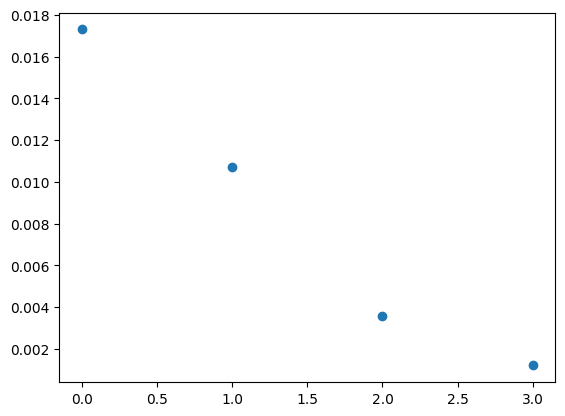

In [36]:
plt.scatter(simulaciones_05.index ,simulaciones_05['Error'])

El numero de simulaciones aumenta el error dismunuye, se acerca al real.